In [11]:
import pickle
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt



# LOAD GRAPH SETS

with open("shortest_path_id_new_graphs.pkl", "rb") as f:
    id_graphs = pickle.load(f)

with open("shortest_path_ood_size_graphs.pkl", "rb") as f:
    ood_graphs = pickle.load(f)

with open("shortest_path_wood_graphs.pkl", "rb") as f:
    wood_graphs = pickle.load(f)



# GRAPH-LEVEL TOPOLOGY METRICS

def compute_graph_metrics(record, dataset_name):

    G = record["G"]
    s = record["s"]
    t = record["t"]

    n = G.number_of_nodes()
    m = G.number_of_edges()

    # total directed degree = in-degree + out-degree
    degrees = np.array([G.in_degree(v) + G.out_degree(v) for v in G.nodes()], dtype=float)

    avg_degree = degrees.mean()

    degree_std = degrees.std()

    degree_cv = (degree_std / avg_degree if avg_degree > 0 else np.nan)

    max_degree = degrees.max()


    # SHORTEST PATH CHARACTERISTICS

    try:
        shortest_path_hops = nx.shortest_path_length(G, source=s, target=t)
        
    except nx.NetworkXNoPath:
        shortest_path_hops = np.nan

    try:
        weighted_shortest_path = nx.shortest_path_length(G, source=s, target=t, weight="dist")
        
    except nx.NetworkXNoPath:
        weighted_shortest_path = np.nan


    # SOURCE-SINK EDGE CONNECTIVITY

    try:
        st_edge_connectivity = nx.edge_connectivity(G, s, t)
        
    except nx.NetworkXError:
        st_edge_connectivity = np.nan


    # RECIPROCITY

    reciprocity = nx.reciprocity(G)
    

    # EDGE BETWEENNESS

    edge_betweenness = nx.edge_betweenness_centrality(G, normalized=True)

    betweenness_values = np.array(list(edge_betweenness.values()), dtype=float)

    max_edge_betweenness = (betweenness_values.max() if len(betweenness_values) > 0 else np.nan)

    mean_edge_betweenness = (betweenness_values.mean() if len(betweenness_values) > 0 else np.nan)

    edge_betweenness_cv = (betweenness_values.std() / mean_edge_betweenness if mean_edge_betweenness > 0 else np.nan)



    return {"dataset": dataset_name, "n_nodes": n, "n_arcs": m, "density": m / n, "avg_degree": avg_degree,
            "degree_std": degree_std, "degree_cv": degree_cv, "max_degree": max_degree,
            "shortest_path_hops": shortest_path_hops, "weighted_shortest_path": weighted_shortest_path,
            "st_edge_connectivity": st_edge_connectivity, "reciprocity": reciprocity, 
            "max_edge_betweenness": max_edge_betweenness, "edge_betweenness_cv": edge_betweenness_cv,}


# BUILD DATAFRAME

rows = []

for record in id_graphs:
    rows.append(compute_graph_metrics(record, "ID"))

for record in ood_graphs:
    rows.append(compute_graph_metrics(record, "OOD"))

for record in wood_graphs:
    rows.append(compute_graph_metrics(record, "Wood"))

metrics_df = pd.DataFrame(rows)

metrics_df.head()

,dataset,n_nodes,n_arcs,density,avg_degree,degree_std,degree_cv,max_degree,shortest_path_hops,weighted_shortest_path,st_edge_connectivity,reciprocity,max_edge_betweenness,edge_betweenness_cv
0,ID,30,60,2.0,4.0,1.751190,0.437798,9.0,2,10,3,0.066667,0.250000,0.852967
1,ID,30,60,2.0,4.0,1.483240,0.370810,7.0,5,22,1,0.066667,0.237739,0.961976
2,ID,30,60,2.0,4.0,1.483240,0.370810,7.0,7,25,1,0.000000,0.236494,0.836119
3,ID,30,60,2.0,4.0,1.570563,0.392641,7.0,5,30,1,0.066667,0.050575,0.739488
4,ID,30,60,2.0,4.0,1.673320,0.418330,9.0,7,47,1,0.100000,0.129847,0.661414


In [13]:
summary = (
    metrics_df
    .groupby("dataset")
    .agg({
        "n_nodes": ["mean", "min", "max"],
        "density": ["mean", "min", "max"],
        "degree_cv": ["mean", "min", "max"],
        "max_degree": ["mean", "min", "max"],
        "shortest_path_hops": ["mean", "min", "max"],
        "weighted_shortest_path": ["mean", "min", "max"],
        "st_edge_connectivity": ["mean", "min", "max"],
        "reciprocity": ["mean", "min", "max"],
        "max_edge_betweenness": ["mean", "min", "max"],
        "edge_betweenness_cv": ["mean", "min", "max"],
    })
)

summary

n_nodes             density                     degree_cv  \
               mean  min  max      mean       min       max      mean   
dataset                                                                 
ID        51.666667   30   75  3.750000  2.000000  6.000000  0.337688   
OOD      325.000000  100  600  4.357143  2.000000  8.000000  0.331566   
Wood      86.500000   51  146  3.935885  3.686275  4.232877  0.336484   

                            max_degree  ... st_edge_connectivity reciprocity  \
              min       max       mean  ...                  max        mean   
dataset                                 ...                                    
ID       0.180021  0.540062  13.558333  ...                   10    0.086491   
OOD      0.197840  0.465027  17.237500  ...                   11    0.021178   
Wood     0.293331  0.371180  10.500000  ...                   12    0.336310   

                            max_edge_betweenness                      \
              min       max                 mean       min       max   
dataset                                                                
ID       0.000000  0.244444             0.087732  0.012920  0.383716   
OOD      0.000000  0.112500             0.028658  0.001987  0.167958   
Wood     0.319149  0.355987             0.017558  0.012855  0.021442   

        edge_betweenness_cv                      
                       mean       min       max  
dataset                                          
ID                 0.653186  0.319998  1.230186  
OOD                0.631824  0.341243  1.206075  
Wood               0.550936  0.508009  0.603446  

[3 rows x 30 columns]

In [15]:
def plot_metric_histogram(df, metric, bins=20):

    plt.figure(figsize=(9, 6))

    for dataset in ["ID", "OOD", "Wood"]:

        values = (df.loc[df["dataset"] == dataset, metric].dropna())

        plt.hist(values, bins=bins, alpha=0.5, label=dataset)

    plt.xlabel(metric)
    plt.ylabel("Number of Graphs")
    plt.title(f"Distribution of {metric}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

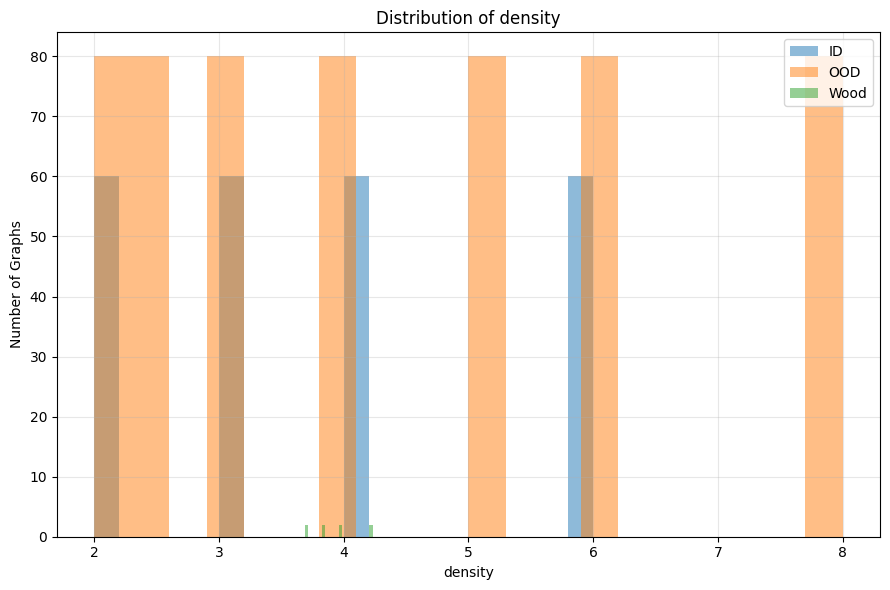

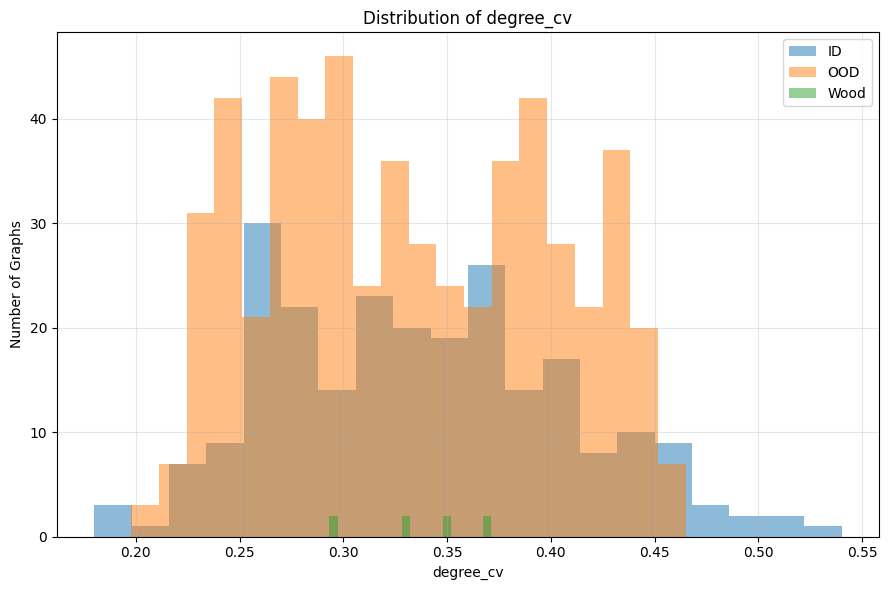

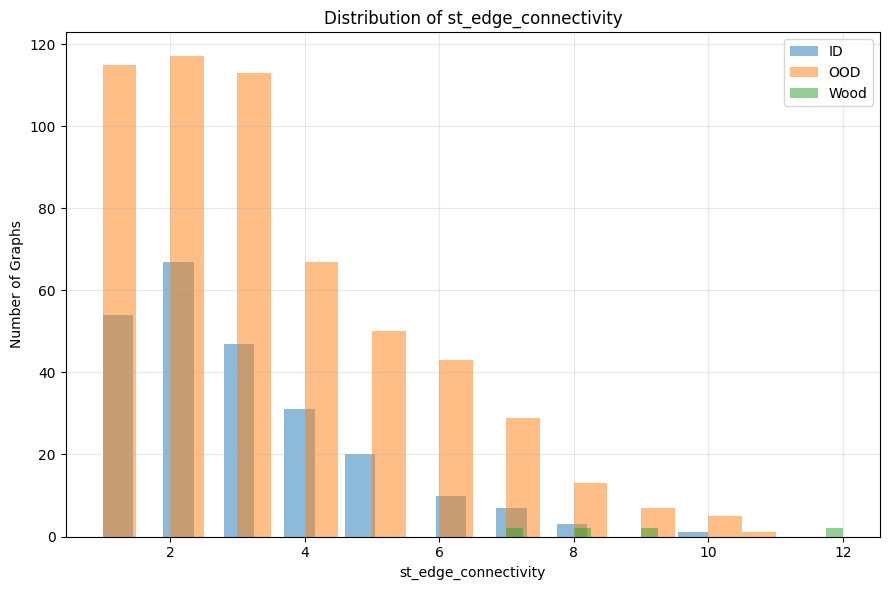

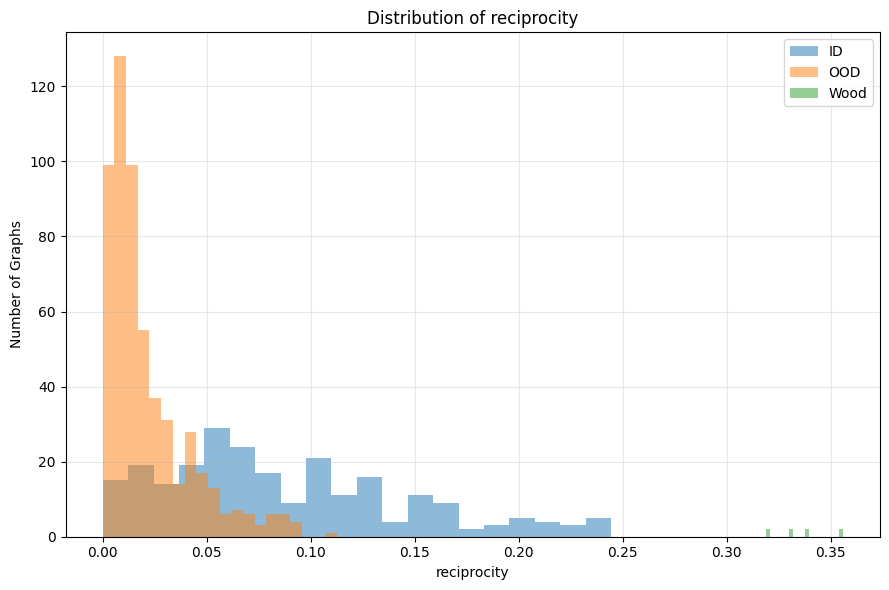

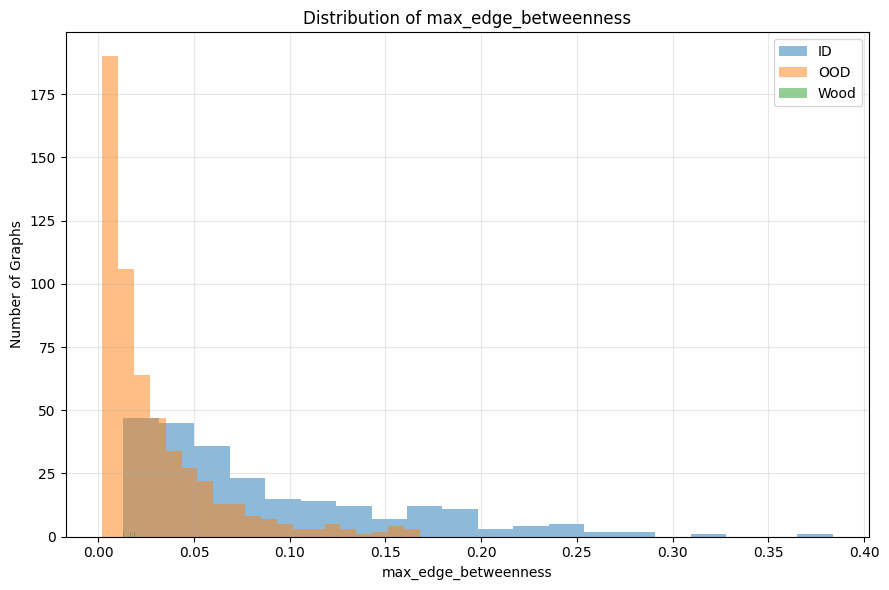

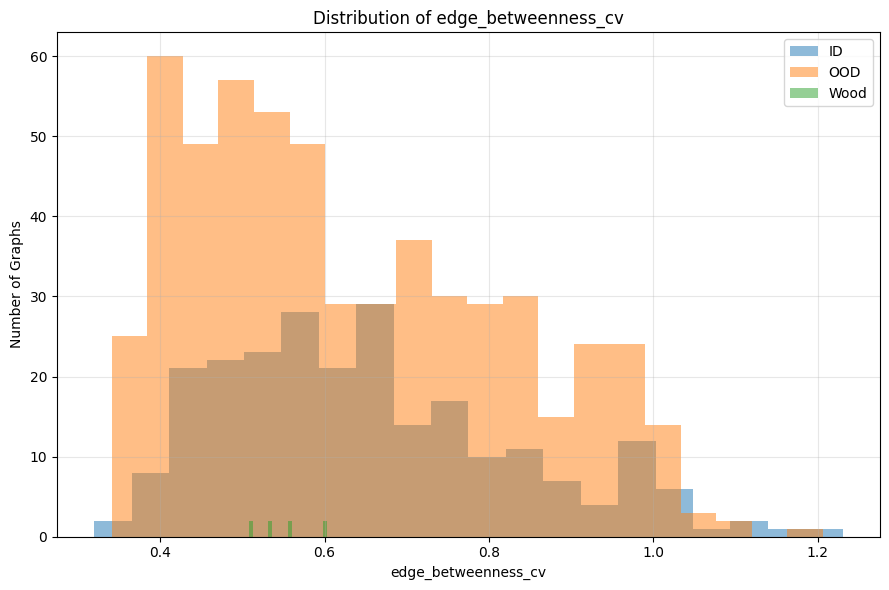

In [17]:
plot_metric_histogram(metrics_df, "density")
plot_metric_histogram(metrics_df, "degree_cv")
plot_metric_histogram(metrics_df, "st_edge_connectivity")
plot_metric_histogram(metrics_df, "reciprocity")
plot_metric_histogram(metrics_df, "max_edge_betweenness")
plot_metric_histogram(metrics_df, "edge_betweenness_cv")

#### One-In graphs tend to have less source-to-sink redundancy, less bidirectional structure, and a greater possibility of individual structurally important arcs.

#### Wood has many more independent \(s-t\) routes, much more reciprocal structure, and no single arc that is nearly as structurally dominant.

In [ ]:
plot_metric_histogram(metrics_df, "max_degree")
plot_metric_histogram(metrics_df, "shortest_path_hops")
plot_metric_histogram(metrics_df, "weighted_shortest_path")